In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (48536, 28)


Federated Round 1/20 | Accuracy: 0.3396
Federated Round 2/20 | Accuracy: 0.3378
Federated Round 3/20 | Accuracy: 0.3375
Federated Round 4/20 | Accuracy: 0.3391
Federated Round 5/20 | Accuracy: 0.3393
Federated Round 6/20 | Accuracy: 0.3329
Federated Round 7/20 | Accuracy: 0.3311
Federated Round 8/20 | Accuracy: 0.3385
Federated Round 9/20 | Accuracy: 0.3345
Federated Round 10/20 | Accuracy: 0.3318
Federated Round 11/20 | Accuracy: 0.3346
Federated Round 12/20 | Accuracy: 0.3282
Federated Round 13/20 | Accuracy: 0.3337
Federated Round 14/20 | Accuracy: 0.3340
Federated Round 15/20 | Accuracy: 0.3291
Federated Round 16/20 | Accuracy: 0.3276
Federated Round 17/20 | Accuracy: 0.3277
Federated Round 18/20 | Accuracy: 0.3272
Federated Round 19/20 | Accuracy: 0.3352
Federated Round 20/20 | Accuracy: 0.3307
===== OVERALL METRICS FOR MOTOR_SYMPTOMS =====
Accuracy : 0.3307
Precision: 0.3308
Recall   : 0.3306
F1-score : 0.3231


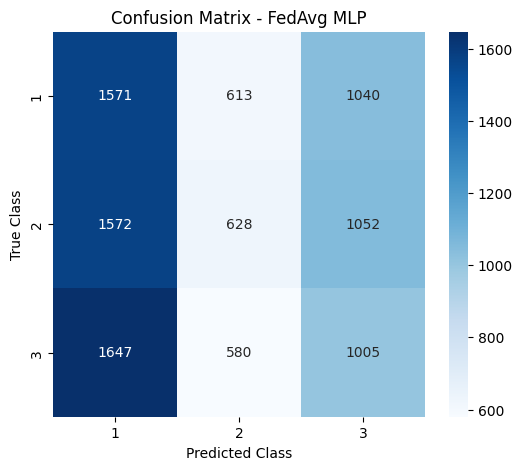

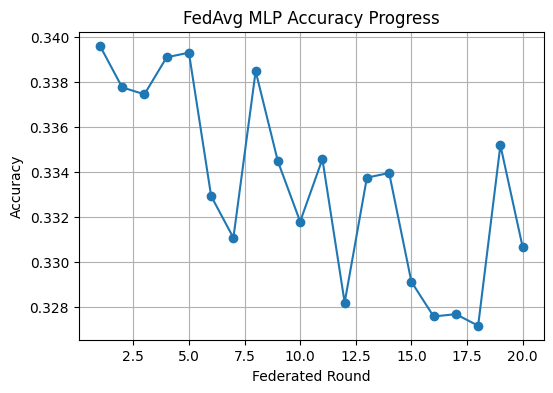

In [ ]:
# ================================
# IMPROVED FEDAVG MLP FOR MOTOR_SYMPTOMS
# ================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


# Drop non-numeric columns
df = df.drop(columns=["Patient_ID","Random_Protein_Sequence","Random_Gene_Sequence","Chromosome_Location"])

# Features & target
X = df.drop(columns=["Motor_Symptoms"]).values
y = df["Motor_Symptoms"].values - 1  # Convert to 0,1,2 for PyTorch

# -------------------------------
# 2. TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 3. SPLIT TRAINING DATA INTO CLIENTS
# -------------------------------
NUM_CLIENTS = 5
client_indices = np.array_split(np.arange(len(X_train)), NUM_CLIENTS)
clients = []
for idx in client_indices:
    clients.append((X_train[idx], y_train[idx]))

# -------------------------------
# 4. DEFINE IMPROVED MLP
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=3, dropout=0.3):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.model(x)

# -------------------------------
# 5. FEDERATED TRAINING
# -------------------------------
ROUNDS = 20
EPOCHS = 15
BATCH_SIZE = 32
LR = 0.001
input_size = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize global model
global_model = MLP(input_size).to(device)
loss_fn = nn.CrossEntropyLoss()

accuracy_list = []

for r in range(ROUNDS):
    local_models = []

    for X_client, y_client in clients:
        local_model = MLP(input_size).to(device)
        local_model.load_state_dict(global_model.state_dict())  # Start from global
        optimizer = optim.Adam(local_model.parameters(), lr=LR)

        dataset = TensorDataset(torch.tensor(X_client, dtype=torch.float32),
                                torch.tensor(y_client, dtype=torch.long))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

        local_model.train()
        for epoch in range(EPOCHS):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = local_model(xb)
                loss = loss_fn(outputs, yb)
                loss.backward()
                optimizer.step()

        local_models.append(local_model.state_dict())

    # FedAvg: average weights
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([local_models[i][key].float() for i in range(NUM_CLIENTS)], 0).mean(0)
    global_model.load_state_dict(global_dict)

    # Evaluate global model
    global_model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = global_model(X_test_tensor)
        y_pred_labels = torch.argmax(y_pred, dim=1).cpu().numpy()
    acc = accuracy_score(y_test, y_pred_labels)
    accuracy_list.append(acc)
    print(f"Federated Round {r+1}/{ROUNDS} | Accuracy: {acc:.4f}")


# -------------------------------
# Overall metrics for Motor_Symptoms
# -------------------------------

# Accuracy
overall_accuracy = accuracy_score(y_test, y_pred_labels)

# Precision, Recall, F1-score (macro average)
overall_precision = precision_score(y_test, y_pred_labels, average='macro')
overall_recall = recall_score(y_test, y_pred_labels, average='macro')
overall_f1 = f1_score(y_test, y_pred_labels, average='macro')

print("===== OVERALL METRICS FOR MOTOR_SYMPTOMS =====")
print(f"Accuracy : {overall_accuracy:.4f}")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall   : {overall_recall:.4f}")
print(f"F1-score : {overall_f1:.4f}")

# -------------------------------
# 7. CONFUSION MATRIX HEATMAP
# -------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - FedAvg MLP")
plt.show()

# -------------------------------
# 8. ACCURACY vs Rounds PLOT
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(range(1, ROUNDS+1), accuracy_list, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Accuracy")
plt.title("FedAvg MLP Accuracy Progress")
plt.grid(True)
plt.show()


Federated Round 1/20 | Accuracy: 0.2521
Federated Round 2/20 | Accuracy: 0.2494
Federated Round 3/20 | Accuracy: 0.2443
Federated Round 4/20 | Accuracy: 0.2443
Federated Round 5/20 | Accuracy: 0.2441
Federated Round 6/20 | Accuracy: 0.2475
Federated Round 7/20 | Accuracy: 0.2467
Federated Round 8/20 | Accuracy: 0.2454
Federated Round 9/20 | Accuracy: 0.2430
Federated Round 10/20 | Accuracy: 0.2482
Federated Round 11/20 | Accuracy: 0.2527
Federated Round 12/20 | Accuracy: 0.2485
Federated Round 13/20 | Accuracy: 0.2519
Federated Round 14/20 | Accuracy: 0.2491
Federated Round 15/20 | Accuracy: 0.2473
Federated Round 16/20 | Accuracy: 0.2453
Federated Round 17/20 | Accuracy: 0.2536
Federated Round 18/20 | Accuracy: 0.2495
Federated Round 19/20 | Accuracy: 0.2486
Federated Round 20/20 | Accuracy: 0.2502

===== OVERALL METRICS FOR DISEASE_STAGE =====
Accuracy : 0.2502
Precision: 0.2501
Recall   : 0.2493
F1-score : 0.2410


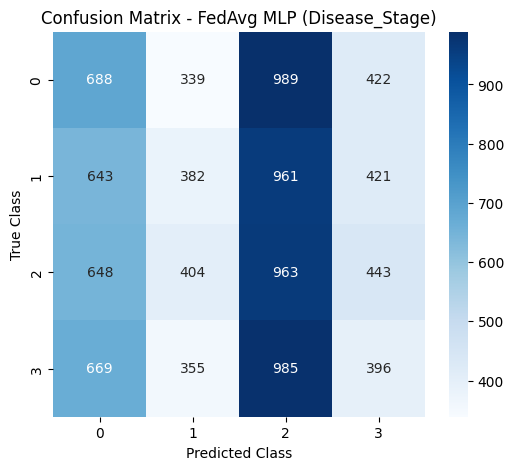

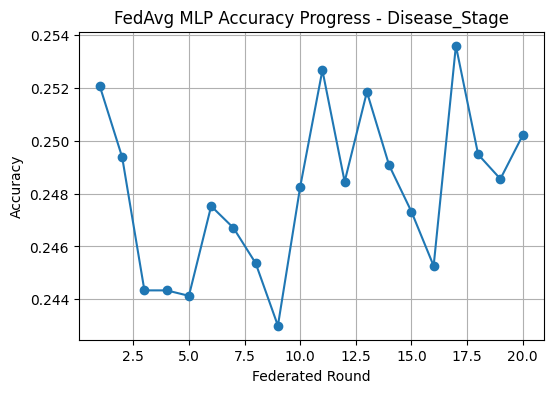

In [ ]:
# ================================
# IMPROVED FEDAVG MLP FOR DISEASE_STAGE
# ================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-numeric columns
df = df.drop(columns=["Patient_ID","Random_Protein_Sequence","Random_Gene_Sequence","Chromosome_Location"])

# Features & target
X = df.drop(columns=["Disease_Stage"]).values
y = df["Disease_Stage"].values  # 0,1,2,3 already

# -------------------------------
# 2. TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 3. SPLIT TRAINING DATA INTO CLIENTS
# -------------------------------
NUM_CLIENTS = 5
client_indices = np.array_split(np.arange(len(X_train)), NUM_CLIENTS)
clients = []
for idx in client_indices:
    clients.append((X_train[idx], y_train[idx]))

# -------------------------------
# 4. DEFINE IMPROVED MLP
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=4, dropout=0.3):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.model(x)

# -------------------------------
# 5. FEDERATED TRAINING
# -------------------------------
ROUNDS = 20
EPOCHS = 15
BATCH_SIZE = 32
LR = 0.001
input_size = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize global model
global_model = MLP(input_size).to(device)
loss_fn = nn.CrossEntropyLoss()

accuracy_list = []

for r in range(ROUNDS):
    local_models = []

    for X_client, y_client in clients:
        local_model = MLP(input_size).to(device)
        local_model.load_state_dict(global_model.state_dict())  # Start from global
        optimizer = optim.Adam(local_model.parameters(), lr=LR)

        dataset = TensorDataset(torch.tensor(X_client, dtype=torch.float32),
                                torch.tensor(y_client, dtype=torch.long))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

        local_model.train()
        for epoch in range(EPOCHS):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = local_model(xb)
                loss = loss_fn(outputs, yb)
                loss.backward()
                optimizer.step()

        local_models.append(local_model.state_dict())

    # FedAvg: average weights
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([local_models[i][key].float() for i in range(NUM_CLIENTS)], 0).mean(0)
    global_model.load_state_dict(global_dict)

    # Evaluate global model
    global_model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = global_model(X_test_tensor)
        y_pred_labels = torch.argmax(y_pred, dim=1).cpu().numpy()
    acc = accuracy_score(y_test, y_pred_labels)
    accuracy_list.append(acc)
    print(f"Federated Round {r+1}/{ROUNDS} | Accuracy: {acc:.4f}")

# -------------------------------
# 6. OVERALL METRICS FOR DISEASE_STAGE
# -------------------------------
overall_accuracy = accuracy_score(y_test, y_pred_labels)
overall_precision = precision_score(y_test, y_pred_labels, average='macro')
overall_recall = recall_score(y_test, y_pred_labels, average='macro')
overall_f1 = f1_score(y_test, y_pred_labels, average='macro')

print("\n===== OVERALL METRICS FOR DISEASE_STAGE =====")
print(f"Accuracy : {overall_accuracy:.4f}")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall   : {overall_recall:.4f}")
print(f"F1-score : {overall_f1:.4f}")

# -------------------------------
# 7. CONFUSION MATRIX HEATMAP
# -------------------------------
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - FedAvg MLP (Disease_Stage)")
plt.show()

# -------------------------------
# 8. ACCURACY vs ROUNDS PLOT
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(range(1, ROUNDS+1), accuracy_list, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Accuracy")
plt.title("FedAvg MLP Accuracy Progress - Disease_Stage")
plt.grid(True)
plt.show()


Federated Round 1/20 | Avg Accuracy: 1.0000
Federated Round 2/20 | Avg Accuracy: 1.0000
Federated Round 3/20 | Avg Accuracy: 1.0000
Federated Round 4/20 | Avg Accuracy: 1.0000
Federated Round 5/20 | Avg Accuracy: 1.0000
Federated Round 6/20 | Avg Accuracy: 1.0000
Federated Round 7/20 | Avg Accuracy: 1.0000
Federated Round 8/20 | Avg Accuracy: 1.0000
Federated Round 9/20 | Avg Accuracy: 1.0000
Federated Round 10/20 | Avg Accuracy: 1.0000
Federated Round 11/20 | Avg Accuracy: 1.0000
Federated Round 12/20 | Avg Accuracy: 1.0000
Federated Round 13/20 | Avg Accuracy: 1.0000
Federated Round 14/20 | Avg Accuracy: 1.0000
Federated Round 15/20 | Avg Accuracy: 1.0000
Federated Round 16/20 | Avg Accuracy: 1.0000
Federated Round 17/20 | Avg Accuracy: 1.0000
Federated Round 18/20 | Avg Accuracy: 1.0000
Federated Round 19/20 | Avg Accuracy: 1.0000
Federated Round 20/20 | Avg Accuracy: 1.0000

===== METRICS FOR Category_Primary Cause =====
              precision    recall  f1-score   support

      

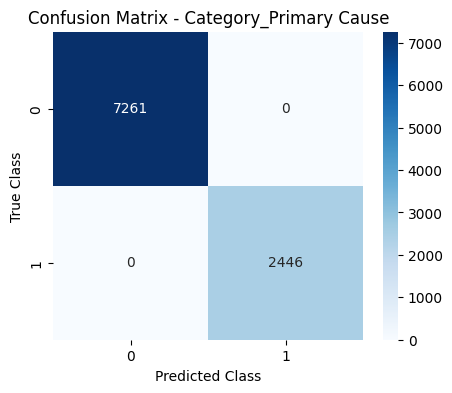


===== METRICS FOR Category_Trans-acting Modifier =====
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      4851
           1     1.0000    1.0000    1.0000      4856

    accuracy                         1.0000      9707
   macro avg     1.0000    1.0000    1.0000      9707
weighted avg     1.0000    1.0000    1.0000      9707



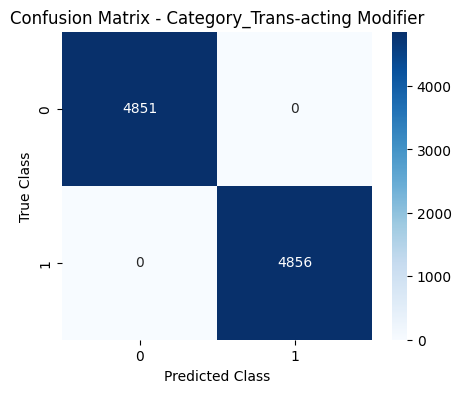

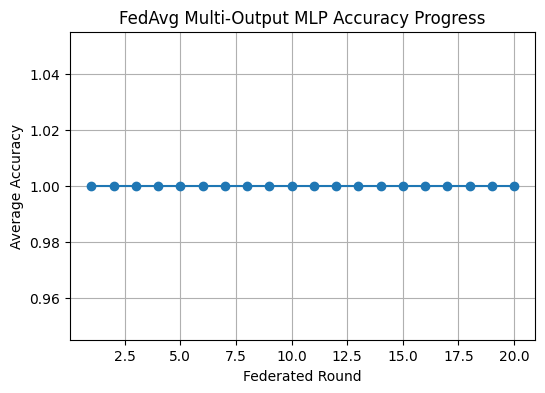

In [ ]:
# ================================
# FEDAVG MLP FOR MULTI-OUTPUT CATEGORY COLUMNS
# ================================

!pip install iterative-stratification -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold


# Drop non-numeric columns
df = df.drop(columns=["Patient_ID","Random_Protein_Sequence","Random_Gene_Sequence","Chromosome_Location"])

# Features & targets
X = df.drop(columns=["Category_Primary Cause","Category_Trans-acting Modifier"]).values
y = df[["Category_Primary Cause","Category_Trans-acting Modifier"]].values  # shape (n_samples,2)

# -------------------------------
# 2. MULTILABEL STRATIFIED SPLIT
# -------------------------------
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in mskf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    break

# -------------------------------
# 3. SPLIT TRAINING DATA INTO CLIENTS
# -------------------------------
NUM_CLIENTS = 5
client_indices = np.array_split(np.arange(len(X_train)), NUM_CLIENTS)
clients = []
for idx in client_indices:
    clients.append((X_train[idx], y_train[idx]))

# -------------------------------
# 4. DEFINE MLP (multi-output)
# -------------------------------
class MultiOutputMLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=2, dropout=0.3):
        super(MultiOutputMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.model(x)

# -------------------------------
# 5. FEDERATED TRAINING
# -------------------------------
ROUNDS = 20
EPOCHS = 15
BATCH_SIZE = 32
LR = 0.001
input_size = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_model = MultiOutputMLP(input_size).to(device)
loss_fn = nn.BCEWithLogitsLoss()  # multi-label binary

accuracy_list = []

for r in range(ROUNDS):
    local_models = []

    for X_client, y_client in clients:
        local_model = MultiOutputMLP(input_size).to(device)
        local_model.load_state_dict(global_model.state_dict())
        optimizer = optim.Adam(local_model.parameters(), lr=LR)

        dataset = TensorDataset(torch.tensor(X_client, dtype=torch.float32),
                                torch.tensor(y_client, dtype=torch.float32))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

        local_model.train()
        for epoch in range(EPOCHS):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = local_model(xb)
                loss = loss_fn(outputs, yb)
                loss.backward()
                optimizer.step()

        local_models.append(local_model.state_dict())

    # FedAvg
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([local_models[i][key].float() for i in range(NUM_CLIENTS)], 0).mean(0)
    global_model.load_state_dict(global_dict)

    # Evaluate
    global_model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = torch.sigmoid(global_model(X_test_tensor)).cpu().numpy()
        y_pred_labels = (y_pred > 0.5).astype(int)

    acc = np.mean(y_pred_labels == y_test)
    accuracy_list.append(acc)
    print(f"Federated Round {r+1}/{ROUNDS} | Avg Accuracy: {acc:.4f}")

# -------------------------------
# 6. METRICS PER CATEGORY
# -------------------------------
for i, col in enumerate(["Category_Primary Cause","Category_Trans-acting Modifier"]):
    print(f"\n===== METRICS FOR {col} =====")
    print(classification_report(y_test[:,i], y_pred_labels[:,i], digits=4))
    cm = confusion_matrix(y_test[:,i], y_pred_labels[:,i])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(f"Confusion Matrix - {col}")
    plt.show()

# -------------------------------
# 7. ACCURACY vs ROUNDS PLOT
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(range(1, ROUNDS+1), accuracy_list, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Average Accuracy")
plt.title("FedAvg Multi-Output MLP Accuracy Progress")
plt.grid(True)
plt.show()
